# Exercise 2:
### Latent Dirichlet Allocation (LDA)

For this exercise, we will be using the `ds-qna-data.csv` dataset containing the following columns header:
 - question
 - answer

Perform the necessary cleaning and preprocessing of the data and subsequently used it to trained the model for LDA.

---

#### Load libraries

In [1]:
!pip install gensim
!pip install gensim pandas pyLDAvis
!pip install nltk
!pip install numpy==1.24.2  # Replace with the compatible version
!pip install --upgrade scipy

  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.2
    Uninstalling scipy-1.15.2:
      Successfully uninstalled scipy-1.15.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.2 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.24.2 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.2 which is incompatible.
pymc 5.21.1 requires numpy>=1.25.0, but you have numpy 1.24.2 which is incompatible.
albumentations 2.0.5 requires numpy>=1.24.4, but you have numpy 1.24.2 which is incompatible.
  Using cached scipy-1.15.2-cp3

In [2]:
# import necessary libraries
# import necessary libraries
import pandas as pd
import re
import gensim.parsing.preprocessing as preprocessing
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
from gensim import corpora, models
import pyLDAvis
import pyLDAvis.gensim

#### Load dataset

In [3]:
# Load the dataset
df = pd.read_csv('ds-qna-data.csv')
df.head()

,question,answer
0,What is supervised machine learning? 👶,Supervised learning is a type of machine learn...
1,What is regression? Which models can you use t...,Regression is a part of supervised ML. Regress...
2,What is linear regression? When do we use it? 👶,Linear regression is a model that assumes a li...
3,What are the main assumptions of linear regres...,There are several assumptions of linear regres...
4,What’s the normal distribution? Why do we care...,The normal distribution is a continuous probab...


In [4]:
df.shape

(166, 2)

#### Preprocessing/Cleaning Step

In [5]:
df = df.drop_duplicates(subset=['answer'], keep='first')


In [6]:
df["text"] = df["question"] + " " + df["answer"]

<ipython-input-6-c87ebb7b3385>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text"] = df["question"] + " " + df["answer"]


In [7]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text)
    tokens = simple_preprocess(text)
    # Remove stopwords
    tokens = [token for token in tokens if token not in STOPWORDS]
    return tokens

In [8]:
df["tokens"] = df["text"].apply(clean_text)

<ipython-input-8-c21f27868b90>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tokens"] = df["text"].apply(clean_text)


In [9]:
dictionary = corpora.Dictionary(df["tokens"])
corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

#### Model Training

In [10]:
LDA_model = models.ldamodel.LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes=10, random_state=42)

In [11]:
topics = LDA_model.print_topics(num_words=5)
for idx, topic in topics:
    print("Topic: {} \nWords: {}".format(idx, topic))

Topic: 0 
Words: 0.018*"regularization" + 0.012*"regression" + 0.011*"values" + 0.010*"linear" + 0.010*"distribution"
Topic: 1 
Words: 0.017*"data" + 0.011*"regularization" + 0.010*"features" + 0.009*"activation" + 0.009*"time"
Topic: 2 
Words: 0.026*"model" + 0.014*"learning" + 0.014*"training" + 0.013*"number" + 0.012*"set"
Topic: 3 
Words: 0.019*"gradient" + 0.019*"random" + 0.013*"forest" + 0.013*"tree" + 0.011*"features"
Topic: 4 
Words: 0.014*"true" + 0.013*"false" + 0.013*"words" + 0.011*"use" + 0.011*"models"


In [12]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(LDA_model, corpus, dictionary)
pyLDAvis.display(vis)

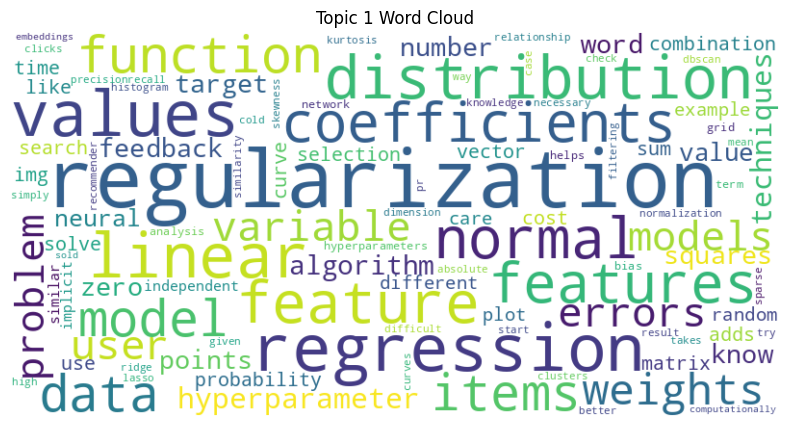

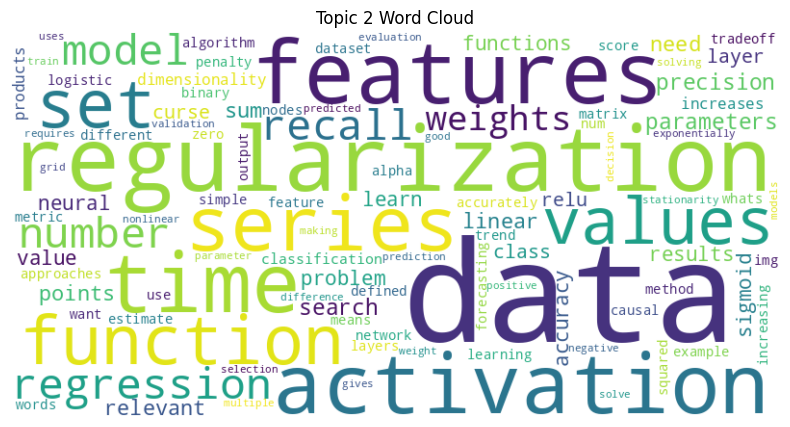

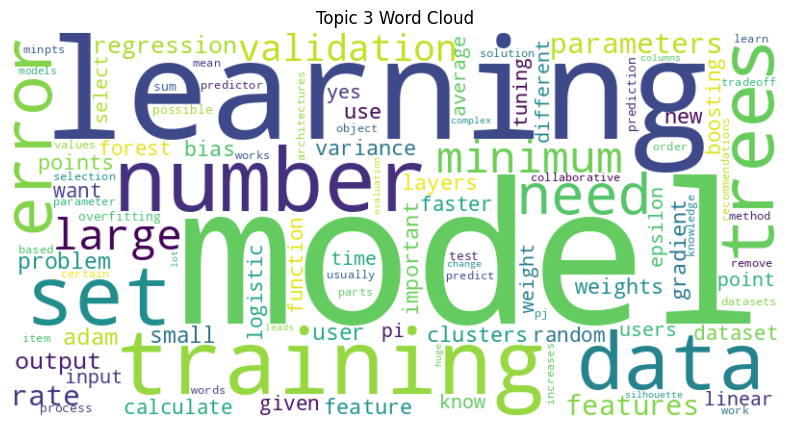

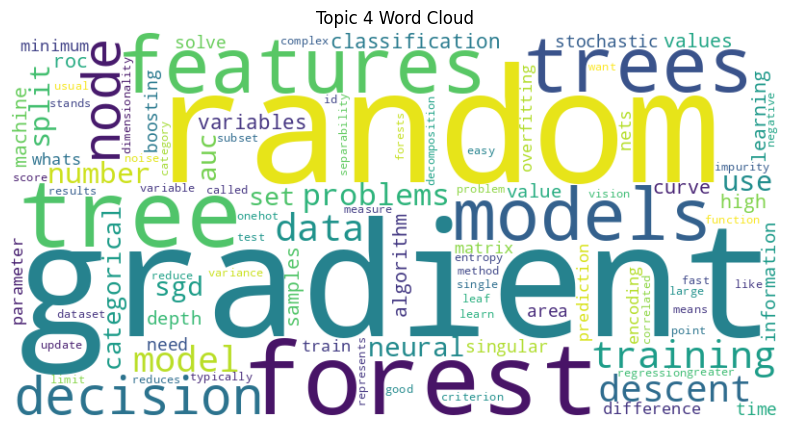

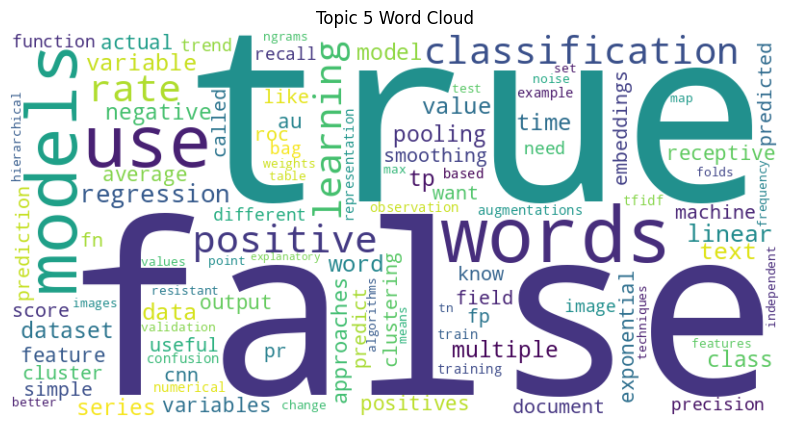

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_idx in range(5):
    topic_words = LDA_model.show_topic(topic_idx, topn=100)
    wordcloud = WordCloud(background_color='white', width=800, height=400).generate_from_frequencies(dict(topic_words))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {topic_idx + 1} Word Cloud')
    plt.show()